In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from functions import log_transform_abundance, pivot_by_protein, filter_high_quality

# === 1. Load and log-transform training data (no mouse kidney) ===
df = pd.read_parquet("all_organisms_filtered_without_M.musculus_KIDNEY.parquet", engine="fastparquet")
#df = filter_high_quality(df)



df = log_transform_abundance(df)

# === 2. Pivot by UniprotAccession for M. musculus ===
mouse_df = pivot_by_protein(df, organism="M.musculus")

# === 3. Load withheld mouse kidney data ===
# Assume this file was just provided
kidney_test = pd.read_csv("train_added_M.musculus_KIDNEY_data.csv")  # Update if filename differs
kidney_test = log_transform_abundance(kidney_test)
kidney_test = pivot_by_protein(kidney_test, organism="M.musculus")

# === 4. Merge training + test (keeping only common UniprotAccessions) ===
# Inner join to keep only the 12,129 proteins
merged = mouse_df.join(kidney_test[['KIDNEY']], how='inner', lsuffix='', rsuffix='_KIDNEY')

# === 5. Save to CSV for inspection or backup ===
merged.to_csv("combined_mouse_data_with_kidney.csv")

# === 6. Train/test split using KIDNEY as target ===
X = merged.drop(columns="KIDNEY")
y = merged["KIDNEY"]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


=== FINAL MODEL: XGBoost + SHAP-Inspired Features + Zero Imputation ===
RMSE: 0.4690
R²: 0.7375
Spearman ρ: 0.8420


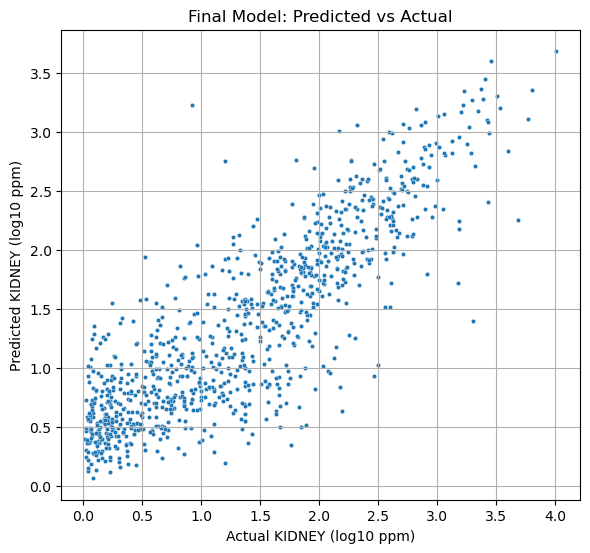

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# === 1. Extract human kidney values by nog_id ===
human_kidney_df = df[
    (df["organism_name"] == "H.sapiens") & 
    (df["sample_organ"] == "KIDNEY")
][["nog_id", "abundance"]].copy()

# === 2. Apply log transform ===
human_kidney_df["abundance"] = np.log10(human_kidney_df["abundance"])
human_kidney_mean = human_kidney_df.groupby("nog_id")["abundance"].mean()

# === 3. Map to mouse dataset via nog_id ===
# You already have merged (mouse_df with UniprotAccession index), let's get nog_id from df
mouse_nog_map = df[df["organism_name"] == "M.musculus"][["UniprotAccession", "nog_id"]].drop_duplicates().set_index("UniprotAccession")
merged_with_nog = merged.join(mouse_nog_map, how="left")

# === 4. Create HUMAN_KIDNEY feature ===
merged_with_nog["HUMAN_KIDNEY"] = merged_with_nog["nog_id"].map(human_kidney_mean)

X_final = merged_with_nog.drop(columns=["KIDNEY", "nog_id"]).copy()
y_final = merged_with_nog["KIDNEY"]

# === 2. Add SHAP-inspired interaction features ===
X_final["LIVERxCORTEX"] = X_final["LIVER"] * X_final["CORTEX_OF_KIDNEY"]
X_final["LIVERxHUMAN"] = X_final["LIVER"] * X_final["HUMAN_KIDNEY"]
X_final["HEARTxLUNG"] = X_final["HEART"] * X_final["LUNG"]

# === 3. Add quantile bin of CORTEX_OF_KIDNEY (safe version)
X_final["CORTEX_BIN"] = pd.qcut(X_final["CORTEX_OF_KIDNEY"], q=4, labels=False)
X_final["CORTEX_BIN"] = X_final["CORTEX_BIN"].fillna(-1).astype(int)

# === 4. Zero impute all remaining missing values
X_final = X_final.fillna(0)

# === 5. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# === 6. Train model
model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# === 7. Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
spearman_corr, _ = spearmanr(y_test, y_pred)

print("=== FINAL MODEL: XGBoost + SHAP-Inspired Features + Zero Imputation ===")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Spearman ρ: {spearman_corr:.4f}")

# === 8. Plot: Predicted vs Actual
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, s=10)
plt.xlabel("Actual KIDNEY (log10 ppm)")
plt.ylabel("Predicted KIDNEY (log10 ppm)")
plt.title("Final Model: Predicted vs Actual")
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()
